In [1]:
import pandas as pd
import numpy as np
# import boto3
# import s3fs
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)  # so V1–V28 don't get truncated

In [2]:
df = pd.read_csv("../datasets/creditcard.csv")

In [3]:
print(df.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')


In [4]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes.value_counts())
print("\nMissing values:", df.isnull().sum().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (284807, 31)

Dtypes:
 float64    30
int64       1
Name: count, dtype: int64

Missing values: 0



Duplicate rows: 1081


In [5]:
counts = df["Class"].value_counts()
pct = df["Class"].value_counts(normalize=True) * 100

print(counts)
print(f"\nFraud rate: {pct[1]:.3f}%")
print(f"A model predicting 'never fraud' would be {pct[0]:.3f}% accurate")

Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.173%
A model predicting 'never fraud' would be 99.827% accurate


/tmp/ipykernel_96471/2181835602.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["Legit (0)", "Fraud (1)"])


/tmp/ipykernel_96471/2181835602.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(["Legit (0)", "Fraud (1)"])


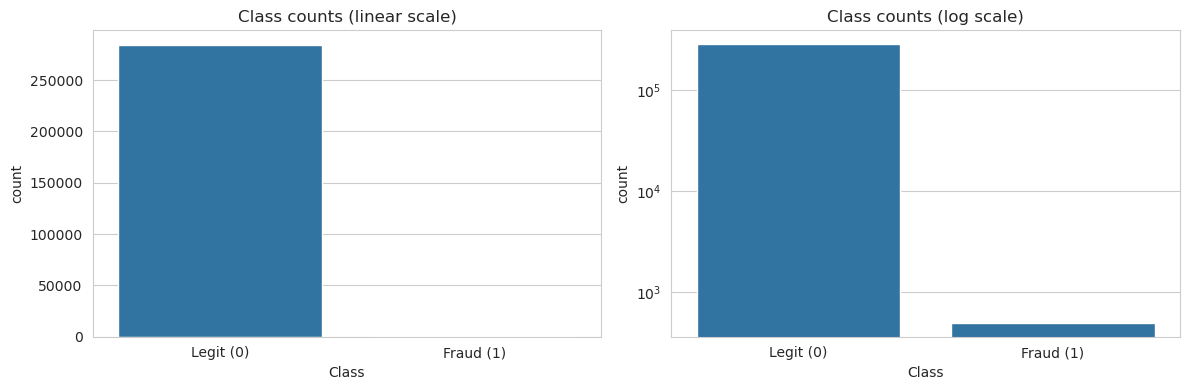

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x="Class", data=df, ax=ax[0])
ax[0].set_title("Class counts (linear scale)")
ax[0].set_xticklabels(["Legit (0)", "Fraud (1)"])

sns.countplot(x="Class", data=df, ax=ax[1])
ax[1].set_yscale("log")
ax[1].set_title("Class counts (log scale)")
ax[1].set_xticklabels(["Legit (0)", "Fraud (1)"])

plt.tight_layout()
plt.savefig("eda_class_imbalance.png", dpi=120, bbox_inches="tight")
plt.show()

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


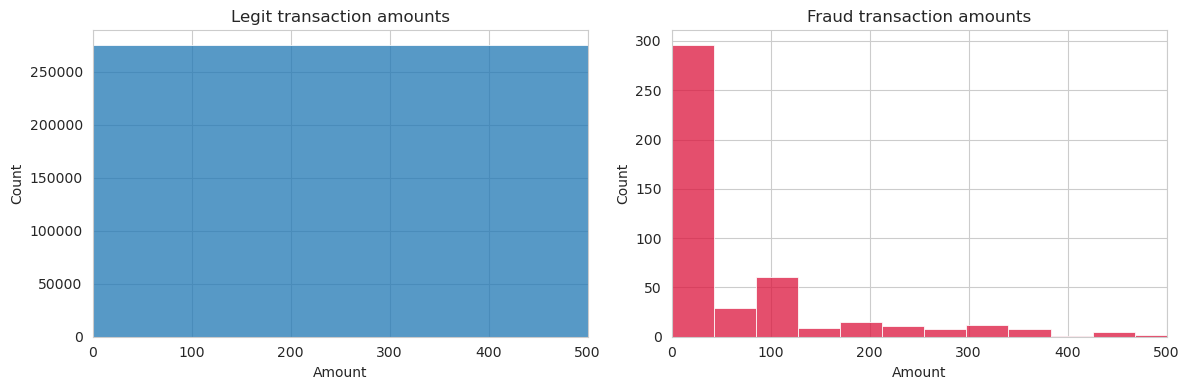

In [10]:
print(df.groupby("Class")["Amount"].describe())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df[df.Class == 0], x="Amount", bins=50, ax=ax[0])
ax[0].set_title("Legit transaction amounts")
ax[0].set_xlim(0, 500)

sns.histplot(data=df[df.Class == 1], x="Amount", bins=50, ax=ax[1], color="crimson")
ax[1].set_title("Fraud transaction amounts")
ax[1].set_xlim(0, 500)

plt.tight_layout()
plt.savefig("eda_amount_by_class.png", dpi=120, bbox_inches="tight")
plt.show()

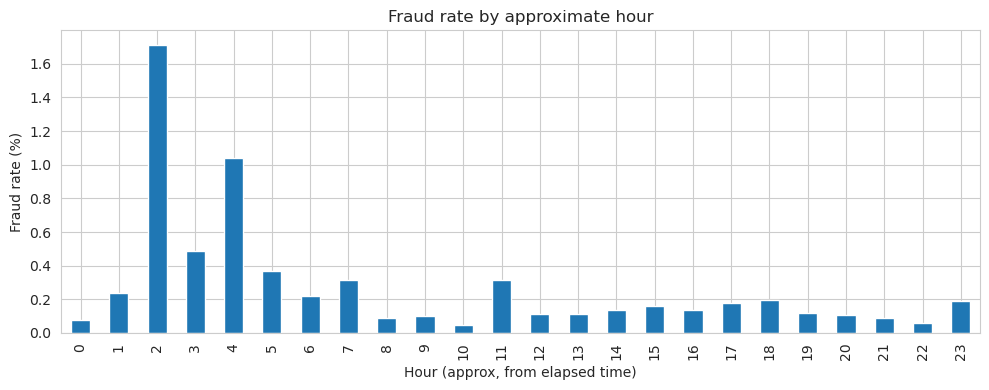

In [7]:
df["hour"] = (df["Time"] / 3600) % 24   # rough hour-of-day proxy

fraud_by_hour = df.groupby(df["hour"].astype(int))["Class"].mean() * 100

plt.figure(figsize=(10, 4))
fraud_by_hour.plot(kind="bar")
plt.ylabel("Fraud rate (%)")
plt.xlabel("Hour (approx, from elapsed time)")
plt.title("Fraud rate by approximate hour")
plt.tight_layout()
plt.savefig("eda_fraud_by_hour.png", dpi=120, bbox_inches="tight")
plt.show()

In [8]:
v_cols = [f"V{i}" for i in range(1, 29)]

# Difference in mean value between fraud and legit, per component
separation = (
    df[df.Class == 1][v_cols].mean() - df[df.Class == 0][v_cols].mean()
).abs().sort_values(ascending=False)

print("Top separating components:\n", separation.head(6))

Top separating components:
 V3     7.045452
V14    6.983787
V17    6.677371
V12    6.270225
V10    5.686707
V7     5.578368
dtype: float64


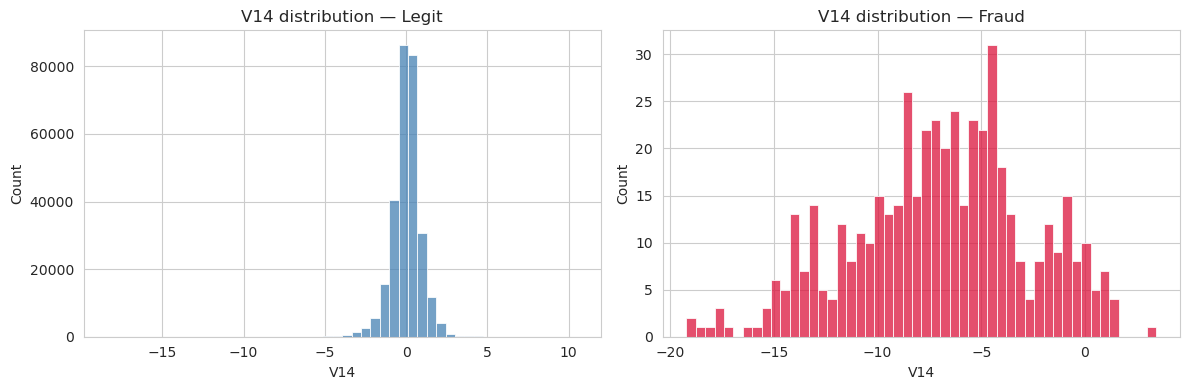

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for cls, a, title in [(0, ax[0], "Legit"), (1, ax[1], "Fraud")]:
    sns.histplot(df[df.Class == cls]["V14"], bins=50, ax=a,
                 color="steelblue" if cls == 0 else "crimson")
    a.set_title(f"V14 distribution — {title}")

plt.tight_layout()
plt.savefig("eda_v14_separation.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
df = df.drop(columns=["hour"])